# Programming in Python II - Final Coding Project

Author: Mariia Kuzmenko

Student ID: k12550768

Save this file under a file name in the format k+matriculation_number.ipynb, e.g. *k1234567.ipynb*. Remember that for final submission all code cells must run without errors and all cells have to be evaluated.

The code cells are a basic scaffold - you can of course add new code cells if necessary. However, stick to the overall structure of the template to facilitate grading. Ensure to comment your code and structure it reasonably.

In [1]:
# This is just a minimum setup for reproducibility. Add more libraries as required.
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd
import glob
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import math
import csv

from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim
from copy import deepcopy
from torch.utils.tensorboard import SummaryWriter

# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = '42'

In [2]:
# checking successful setup
print(f"Using device: {device}")

Using device: cuda


In [3]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [4]:
# Set working directory to the project folder
os.chdir(".") # (already in the project folder)
print(f"Current working directory: {os.getcwd()}")

Current working directory: C:\Users\User\OneDrive - Johannes Kepler Universität Linz\sem2 SS26\prog2\final project


In [5]:
# creating folder 'assets' and necessary subfolders
os.makedirs(os.path.join("assets", "plots"), exist_ok=True)
os.makedirs(os.path.join("assets", "weights"), exist_ok=True)

## Data Handling and Pre-Processing

In [6]:
# your code goes here (preprocess function)

def preprocess(data_folder: str) -> tuple[pd.DataFrame, dict]:
    # Dictionary that maps the numeric labels to the class names
    label_dict = {
        'HerbaceousVegetation': 0,
        'AnnualCrop': 1,
        'Residential': 2,
        'Pasture': 3,
        'Industrial': 4,
        'River': 5,
        'Highway': 6,
        'Forest': 7,
        'PermanentCrop': 8,
        'SeaLake': 9
    }

    # Helper function that maps file names to its corresponding numerical value in dictionary; checks string
    # patterns
    def label_map(file_name: str, label_dict: dict) -> int | None:
            for key in label_dict:
                if key in file_name:
                    return label_dict[key]
            raise ValueError(f"Unmatched filename: {file_name}")

    # Using glob module, extract all images' paths in a list recursively (=in all subdirectories), only if
    # it's a file
    all_images = [i for i in glob.glob(os.path.join(f'{data_folder}', "**"), recursive=True) if os.path.isfile(i)]
    folder = [os.path.dirname(f) for f in all_images] # Extracting folder name of an image
    file_name = [os.path.basename(fn) for fn in all_images] # Extracting file name of an image
    label = [label_map(l, label_dict) for l in all_images] # Extracting label of an image using helper function

    # DataFrame that holds the folder, file name and a numeric label for every image
    image_info = pd.DataFrame(
        {
            'folder': folder,
            'file_name': file_name,
            'label': label
        }
    )

    return image_info, label_dict


In [7]:
# checking successful dataframe loading
image_info, label_dict = preprocess('data')
print(image_info.head(8))
print(f"Length of dataset: {len(image_info)}") # Should be 10000
print(label_dict)

            folder            file_name  label
0  data\AnnualCrop     AnnualCrop_1.jpg      1
1  data\AnnualCrop   AnnualCrop_100.jpg      1
2  data\AnnualCrop  AnnualCrop_1004.jpg      1
3  data\AnnualCrop  AnnualCrop_1005.jpg      1
4  data\AnnualCrop   AnnualCrop_101.jpg      1
5  data\AnnualCrop  AnnualCrop_1014.jpg      1
6  data\AnnualCrop  AnnualCrop_1018.jpg      1
7  data\AnnualCrop  AnnualCrop_1019.jpg      1
Length of dataset: 10000
{'HerbaceousVegetation': 0, 'AnnualCrop': 1, 'Residential': 2, 'Pasture': 3, 'Industrial': 4, 'River': 5, 'Highway': 6, 'Forest': 7, 'PermanentCrop': 8, 'SeaLake': 9}


In [8]:
# Helper reversed label dictionary
reverse_label_dict = {
        0 : 'HerbaceousVegetation',
        1 : 'AnnualCrop',
        2 : 'Residential',
        3 : 'Pasture',
        4 : 'Industrial',
        5 : 'River',
        6 : 'Highway',
        7 : 'Forest',
        8 : 'PermanentCrop',
        9 : 'SeaLake'
    }

In [9]:
# your code goes here (splitting train/validation datasets)

X = image_info[['folder','file_name']] # Input X as folder and file_name columns
y = image_info['label'] # Output y as label column

# Splitting train/validation datasets with a sklearn function
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    train_size=0.8,
    random_state=42,
    stratify=y
)

## Exploratory Data Analysis (EDA)

In [10]:
# your code goes here (show_samples)

def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:

    # Cap grid width at 5 columns to preserve image clarity
    cols = min(num_samples, 5)
    rows = math.ceil(num_samples / 5)
    figure = plt.figure(figsize=(15, 4 * rows))

    for i in range(1, num_samples + 1):
        sample_idx = torch.randint(len(df), size=(1,)).item() # Random sample index from df

        label = df.loc[sample_idx, 'label']
        file_name = df.loc[sample_idx, 'file_name']
        folder = df.loc[sample_idx, 'folder']

        figure.add_subplot(rows, cols, i)
        plt.title('Label: ' + reverse_label_dict[label]) # Mapping numerical label to text
        plt.axis("off")
        image = plt.imread(os.path.join(folder, file_name))
        plt.imshow(image)

    figure.tight_layout() # Automatically tweak spacings to prevent clipping of labels
    figure.savefig(os.path.join('assets', 'plots', 'random_samples.png'))
    plt.show()

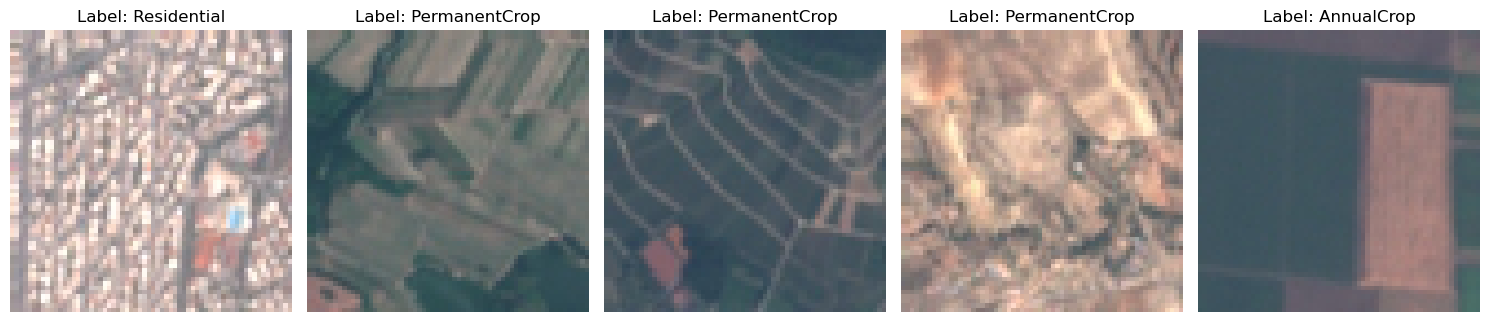

In [11]:
show_samples(image_info)

In [12]:
# your code goes here (average_pixel_plot)

def average_pixel_plot(df: pd.DataFrame)-> None:
    # Accumulating average value of pixel across an image for RGB
    red = []
    green = []
    blue = []

    # Iterate over DataFrame rows as (index, Series) pairs.
    # Iteration approach referenced from official Pandas documentation:
    # [pandas.DataFrame.iterrows — pandas 3.0 documentation]
    # (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html)
    for index, row in df.iterrows():
        image = plt.imread(os.path.join(row['folder'], row['file_name']))

        # Take mean of RGB, respectively
        red.append(np.mean(image[:,:,0]))
        green.append(np.mean(image[:,:,1]))
        blue.append(np.mean(image[:,:,2]))

    fig, ax = plt.subplots()
    ax.hist(red, bins=45, color='red', alpha=0.8) # "alpha" adds translucency
    ax.hist(green, bins=45, color='green', alpha=0.8)
    ax.hist(blue, bins=45, color='blue', alpha=0.8)
    ax.grid(axis='x') # Show grid lines of y-axis
    ax.set_xlabel("Average Pixel Value")
    ax.set_ylabel("Frequency")
    ax.set_title("Distribution of Average Pixel Values")
    fig.savefig(os.path.join('assets', 'plots', 'average_pixel_distribution.png'))
    plt.show()


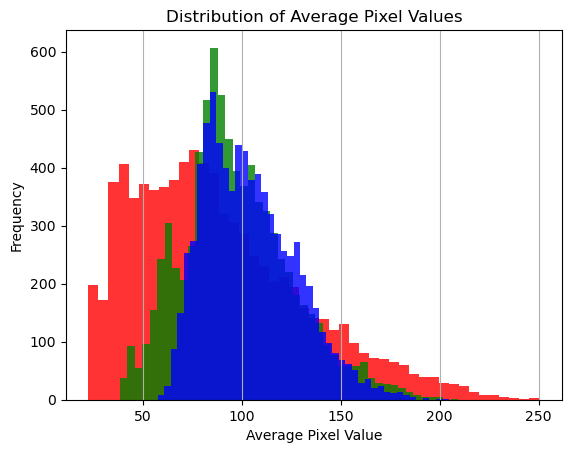

In [13]:
average_pixel_plot(X_train)

In [14]:
# your code goes here (average_brightness_per_class)

def average_brightness_per_class(df: pd.DataFrame)-> None:
    # Dictionary for class names to have each own list
    brightness = {class_name: [] for class_name in label_dict.keys()}

    # Iterate over DataFrame rows as (index, Series) pairs.
    # Iteration approach referenced from official Pandas documentation:
    # [pandas.DataFrame.iterrows — pandas 3.0 documentation]
    # (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html)
    for index, row in df.iterrows():
        image = plt.imread(os.path.join(row['folder'], row['file_name']))
        result_class = os.path.basename(row['folder']) # To which class we will append brightness value
        for i in brightness.keys():
            if result_class == i:
                brightness[i].append(np.mean(image)) # Append average brightness value of image
                break

    data_to_plot = list(brightness.values()) # List of all class lists with values
    labels = list(brightness.keys()) # List of all class labels
    fig, ax = plt.subplots(figsize=(12,6))
    ax.boxplot(data_to_plot, vert=True, tick_labels=labels, # Vertical boxplot
               patch_artist=True, boxprops=dict(facecolor="cyan")) # 'patch_artist' allows for colored boxes, which are set in 'boxprops'
    ax.tick_params('x', rotation=45) # x-axis' labels are 45-degrees-rotated
    ax.grid(axis='x')
    ax.set_ylabel("Average Brightness")
    ax.set_title("Average Brightness Distribution per Class")
    fig.savefig(os.path.join('assets', 'plots', 'average_brightness.png'))
    plt.show()

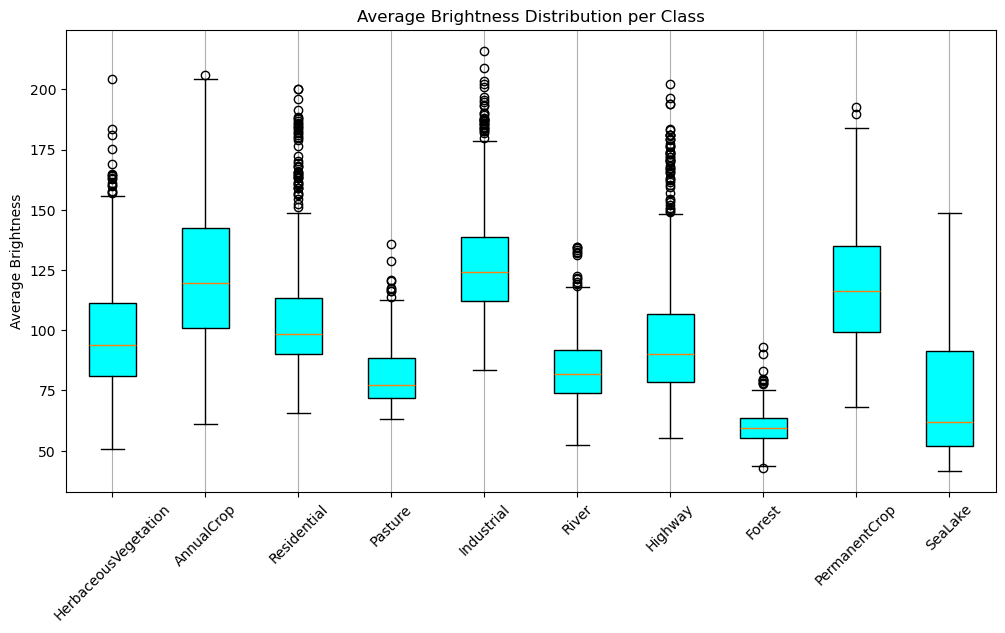

In [15]:
average_brightness_per_class(X_train)

## CNN Implementation and Training

### Dataset class

In [16]:
# your code goes here
# Custom SatelliteDataset class that inherits Dataset class
class SatelliteDataset(Dataset):
    def __init__(self, X, y=None, transform=None): # 'y=None' for my test data that does not have labels
        self.transform = transform
        # X and y are preprocessed dataframes
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        row = self.X.iloc[idx] # Take row from dataset (contains folder and file_name)
        path = os.path.join(row['folder'], row['file_name'])
        img = Image.open(path).convert("RGB") # Convert image to RGB
        if self.transform:
            img = self.transform(img) # For applying transformations
        if self.y is not None: # If labels are given (training/validation)
            label = torch.tensor(self.y.iloc[idx], dtype=torch.long) # covert label to tensor
            return img, label
        else:
            # for test data return file_name for csv file
            return img, row['file_name']

In [17]:
# Because satellite images don't have a "right side up", flipping and
# rotating them helps the model recognize the terrain from any angle.
train_transf = transforms.Compose([
    transforms.RandomHorizontalFlip(), # randomly flip the image horizontally (50% probability)
    transforms.RandomVerticalFlip(), # randomly flip the image vertically (50% probability)
    transforms.RandomRotation(10), # randomly rotate the image by 10 degrees
    transforms.ToTensor() # convert to tensor and scale pixel values to [0, 1]
])

val_transf = transforms.Compose([
    transforms.ToTensor()
])

test_transf = transforms.Compose([
    transforms.ToTensor()
])

In [18]:
# For datasets, preprocessed dataframes are used
train_ds = SatelliteDataset(X=X_train, y=y_train, transform=train_transf)
val_ds   = SatelliteDataset(X=X_val, y=y_val, transform=val_transf)

### Data Loaders

In [19]:
# your code goes here
# For dataloaders, batch of 64 is used, with 'shuffle=True' only in training
train_loader = DataLoader(dataset=train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(dataset=val_ds,  batch_size=64, shuffle=False, num_workers=0)

### Model Architecture

In [20]:
# your code goes here
# Defining SatelliteCNN architecture which inherits nn.Module
class SatelliteCNN(nn.Module):
    """
    A 4-block CNN.

    Batch Normalization is used after the conv layers to keep the training
    stable across the different terrain colors.
    A 0.5 Dropout is used before the output layer to prevent overfitting
    to the training set.
    """
    def __init__(self):
        super().__init__()
        # 4 Convolutional layers (feature extractors)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1) # In: 3 channels (RGB)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)

        # Classifier head (Maps 4096 flattened features down to the 10 target classes)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)

        self.flatten = nn.Flatten() # Flatten the output of the convolutional layers
        self.relu = nn.ReLU() # Introduce non-linearity
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2) # Downsamples by 2
        self.dropout = nn.Dropout(0.5) # Dropout (50% probability, for regularization, only during training)

        # Batch normalization stabilizes the learning step across color channels
        self.batch1 = nn.BatchNorm2d(32)
        self.batch2 = nn.BatchNorm2d(64)
        self.batch3 = nn.BatchNorm2d(128)
        self.batch4 = nn.BatchNorm2d(256)

    def forward(self, x):
        # 1st stage
        x = self.conv1(x)
        x = self.batch1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # 2nd stage
        x = self.conv2(x)
        x = self.batch2(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # 3rd stage
        x = self.conv3(x)
        x = self.batch3(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # 4th stage
        x = self.conv4(x)
        x = self.batch4(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # 5th stage
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [21]:
# Optimizer: Adam (lr=0.001) with a slight weight decay to keep the weights from growing too large.
# Scheduler: StepLR cuts the learning rate in half every 10 epochs so the model takes "smaller steps" as it gets closer to the solution.
# Early Stopping: set to stop if the validation accuracy doesn't improve for 8 epochs, so we save the best version of the model before it starts memorizing the data.

In [22]:
model = SatelliteCNN().to(device) # create an instance of the model
criterion = nn.CrossEntropyLoss() # cross-entropy loss with logits
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)  # Adam with weight decay

In [23]:
# Learning rate scheduler
# Learning rate decay strategy referenced from official PyTorch documentation:
# [torch.optim.lr_scheduler.StepLR — PyTorch 2.12 documentation]
# (https://docs.pytorch.org/docs/2.12/generated/torch.optim.lr_scheduler.StepLR.html)
step_size = 10  # Reduce LR every 10 epochs
gamma = 0.5  # Decay factor
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma) # StepLR scheduler

### Training Loop

In [24]:
# your code goes here
writer = SummaryWriter() # For TensorBoard

num_epochs = 100
train_loss = []   # Accumulate train loss over all epochs
val_loss = []     # Accumulate validation loss over all epochs
best_acc = -1     # Track best accuracy
best_model_params = None     # Track best model parameters s deepcopy of state_dic
best_epoch = 0    # Track best epoch
early_stopping = 8    # Early stopping in 8 epochs
acc_total = []     # Accumulate development of accuracy

for epoch in range(num_epochs):
    model.train()   # Training mode
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (images, labels) in enumerate(train_loader):      # Loop through the training data batches
        images, labels = images.to(device), labels.to(device)    # Move to GPU if available

        optimizer.zero_grad()   # Reset gradients

        outputs = model(images)   # Forward pass
        loss = criterion(outputs, labels)    # Compute loss
        predicted = torch.argmax(outputs, dim=1)   # Get the predicted class (index of the maximum logit)
        total += labels.size(0)     # Add batch size to 'total'
        correct += (predicted == labels).sum().item()   # Add number of correct samples

        loss.backward()   # Backpropagation
        optimizer.step()  # Update the parameters

        running_loss += loss.item() * labels.size(0)

    scheduler.step()  # Step the learning rate decay schedule post-epoch
    train_loss.append(running_loss / total)
    writer.add_scalar('Loss/train', train_loss[-1], epoch)   # Add the training loss to TensorBoard
    acc = 100 * correct / total      # Compute accuracy
    writer.add_scalar('Accuracy/train', acc, epoch)          # Add the training accuracy to TensorBoard

    print(f"-------------- Epoch {epoch + 1}/{num_epochs} --------------")
    print(f"Train loss: {train_loss[-1]:.4f}, Train Accuracy: {acc:.2f}%")

    # evaluate on the validation set
    model.eval()
    correct = 0
    total = 0
    running_loss_val = 0.0

    with torch.no_grad():     # Disable gradient tracking
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            predicted = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            running_loss_val += loss.item() * labels.size(0)

        val_loss.append(running_loss_val / total)
        acc = 100 * correct / total
        acc_total.append(acc)   # Accumulate validation accuracy

        writer.add_scalar('Loss/val', val_loss[-1], epoch)  # add the validation loss to TensorBoard
        writer.add_scalar('Accuracy/val', acc, epoch)       # add the validation accuracy to TensorBoard

        print(f"Val loss:   {val_loss[-1]:.4f}, Val Accuracy:   {acc:.2f}%\n")

        if acc > best_acc:        # save the best model in case of improvement
            best_acc = acc
            best_model_params = deepcopy(model.state_dict())
            best_epoch = epoch

        # Early stopping
        if epoch > 0 and epoch - best_epoch >= early_stopping:
            print(f"Early stopping at epoch {epoch + 1}.\n")
            break

# Save the best model parametres in a file
torch.save(best_model_params, os.path.join('assets', 'weights', 'best_model_params.pth'))
writer.close()

-------------- Epoch 1/100 --------------
Train loss: 1.4266, Train Accuracy: 48.91%
Val loss:   1.0202, Val Accuracy:   61.80%

-------------- Epoch 2/100 --------------
Train loss: 0.8840, Train Accuracy: 69.24%
Val loss:   1.8710, Val Accuracy:   47.10%

-------------- Epoch 3/100 --------------
Train loss: 0.7886, Train Accuracy: 73.21%
Val loss:   0.9637, Val Accuracy:   67.20%

-------------- Epoch 4/100 --------------
Train loss: 0.7468, Train Accuracy: 74.21%
Val loss:   0.9645, Val Accuracy:   69.85%

-------------- Epoch 5/100 --------------
Train loss: 0.6675, Train Accuracy: 77.14%
Val loss:   0.7423, Val Accuracy:   71.45%

-------------- Epoch 6/100 --------------
Train loss: 0.6361, Train Accuracy: 78.60%
Val loss:   0.7736, Val Accuracy:   74.45%

-------------- Epoch 7/100 --------------
Train loss: 0.6022, Train Accuracy: 79.67%
Val loss:   0.5524, Val Accuracy:   81.15%

-------------- Epoch 8/100 --------------
Train loss: 0.5441, Train Accuracy: 81.96%
Val loss:   

## Model Evaluation

In [25]:
# your code goes here (plot_training_curves)
def plot_training_curves(train_loss: list, val_loss: list, acc_total: list) -> None:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Training & Validation Loss plot
    ax[0].plot(train_loss, label='Training Loss')
    ax[0].plot(val_loss, label='Validation Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].set_title('Training & Validation Loss')

    # Validation Accuracy Development plot
    ax[1].plot(acc_total, label='Validation Accuracy')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy (%)')
    ax[1].legend()
    ax[1].set_title('Validation Accuracy Development')

    fig.tight_layout()
    fig.savefig(os.path.join('assets', 'plots', 'training_curves.png'))
    plt.show()

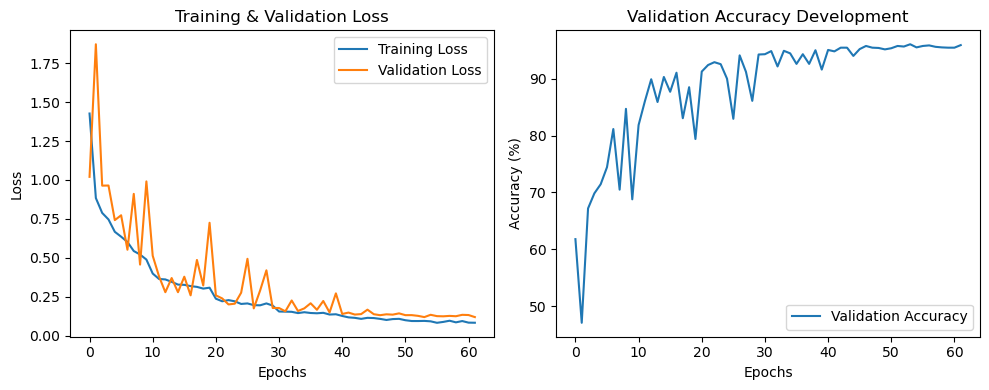

In [26]:
plot_training_curves(train_loss, val_loss, acc_total)

In [27]:
# your code goes here (plot_confusion_matrix)
# Helper function that will plot the confusion matrix
def plot_confusion_matrix(cm, classes, figsize=(10, 8), title='Confusion Matrix'):
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    threshold = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > threshold else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.colorbar()
    plt.savefig(os.path.join('assets', 'plots', 'confusion_matrix.png'))
    plt.show()

all_true_labels = []   # List of all true labels of images
all_pred_labels = []   # List of all predicted labels of images

# Loading the weights and Evaluation mode
model.load_state_dict(torch.load(os.path.join('assets', 'weights', 'best_model_params.pth'), weights_only=True))
model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        # Get the batch predictions
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)

        # .extend() unrolls the batch and dumps the numbers into lists
        all_true_labels.extend(labels.cpu().numpy())
        all_pred_labels.extend(predicted.cpu().numpy())

ordered_classes = [reverse_label_dict[i] for i in range(10)]   # List of classes
cm = confusion_matrix(all_true_labels,  all_pred_labels)   # Using scikit learn

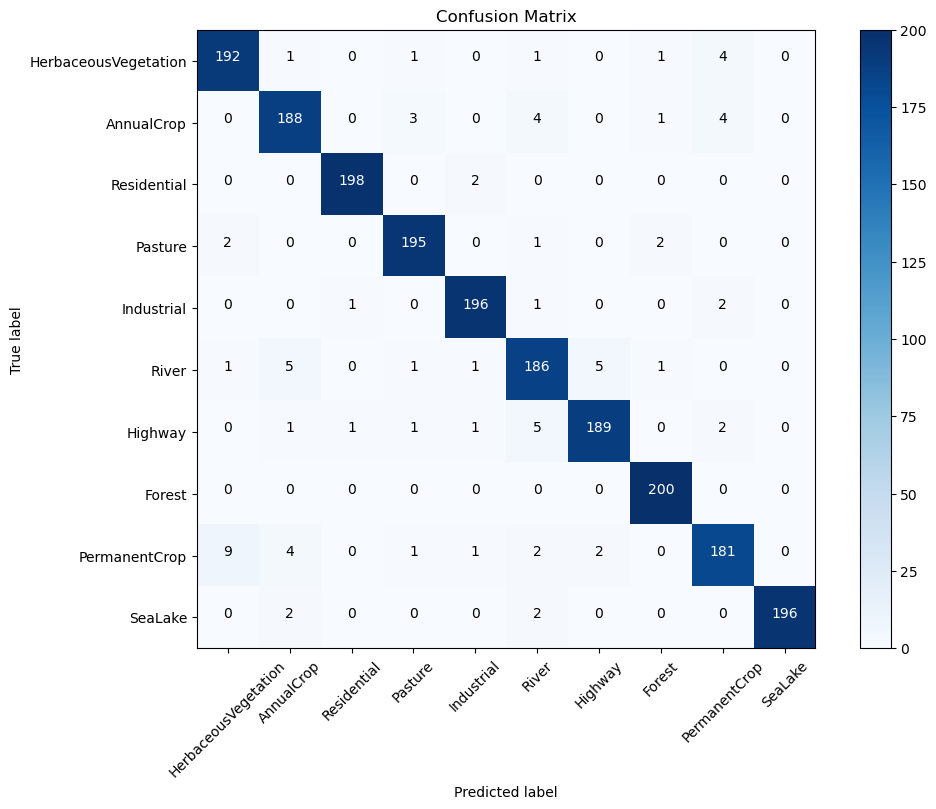

In [28]:
plot_confusion_matrix(cm, classes=ordered_classes)

In [29]:
# your code goes here (plot_misclassified_samples)

def plot_misclassified_samples():
    miscl_imgs  = []         # List of misclassified images
    miscl_true_labels = []   # List of true labels of misclassified images
    miscl_predicted_labels = []     # List of predicted labels of misclassified images

    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)

            for i in range(len(labels)):
                if predicted[i] != labels[i].to(device):   # If predicted label is not the true label

                    miscl_imgs.append(images[i].cpu())
                    miscl_true_labels.append(labels[i].item())
                    miscl_predicted_labels.append(predicted[i].item())

                    if len(miscl_imgs) == 5:  # Break if we have 5
                        break

            if len(miscl_imgs) == 5:  # Break if we have 5
                break

    fig, ax = plt.subplots(1, 5, figsize=(15, 3))
    for i in range(5):

        ax[i].set_title(f'Predicted: {reverse_label_dict[miscl_predicted_labels[i]]}; \nTrue: {reverse_label_dict[miscl_true_labels[i]]}')
        ax[i].axis("off")
        ax[i].imshow(miscl_imgs[i].permute(1, 2, 0).cpu().numpy()) # permute the dimensions to (H, W, C)

    fig.tight_layout()
    fig.savefig(os.path.join('assets', 'plots', 'misclassified_samples.png'))
    plt.show()

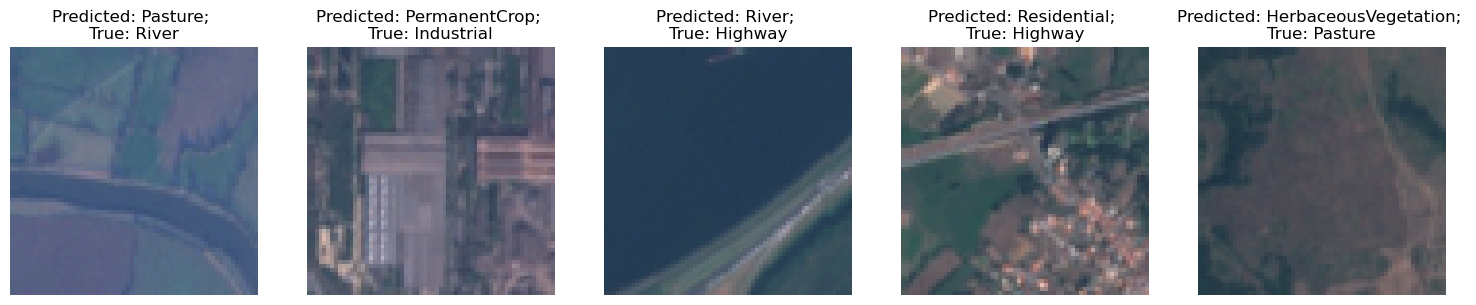

In [30]:
plot_misclassified_samples()

### Test Set

In [31]:
# your code goes here (preprocess_test_data)
def preprocess_test(data_folder: str)-> pd.DataFrame:

    # Using glob module, extract all test images' paths in a list, only if it's a file
    all_images = [i for i in glob.glob(os.path.join(f'{data_folder}', "*")) if os.path.isfile(i)]
    folder = [os.path.dirname(f) for f in all_images] # Extracting folder name of an image
    file_name = [os.path.basename(fn) for fn in all_images] # Extracting file name of an image

    # DataFrame that holds the folder, file name for every test image
    image_info_test = pd.DataFrame(
        {
            'folder': folder,
            'file_name': file_name,
        }
    )

    return image_info_test

In [32]:
image_info_test = preprocess_test('public_test_data')
print(image_info_test.head())

             folder file_name
0  public_test_data  1001.jpg
1  public_test_data  1002.jpg
2  public_test_data  1008.jpg
3  public_test_data   101.jpg
4  public_test_data  1034.jpg


In [33]:
# your code goes here (create dataset and dataloader)
test_ds = SatelliteDataset(X=image_info_test, y=None, transform=test_transf) # 'y=None' no labels provided
test_loader = DataLoader(dataset=test_ds, batch_size=64, shuffle=False, num_workers=0)

In [34]:
# your code goes here (evaluate model on test set)
model.load_state_dict(torch.load(os.path.join('assets', 'weights', 'best_model_params.pth'), weights_only=True))
model.eval()

results = []  # List that will hold lists of info of test images

with torch.no_grad():
    for images, file_names in test_loader:
        images = images.to(device)
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        for file_name, predicted in zip(file_names, predicted):
                label = reverse_label_dict[predicted.item()]   # Get predicted text label
                results.append([file_name, label])  # Append a list of info of an image

In [35]:
# your code goes here (create submission csv file for challenge server)
# CSV generation referenced from official Python standard library documentation:
# [csv — CSV File Reading and Writing — Python 3 documentation]
# (https://docs.python.org/3/library/csv.html#csv.writer)
with open('submission.csv', mode='w', newline='') as file:  # Creates a file, write mode
    writer_csv = csv.writer(file)
    writer_csv.writerows(results)